# Importing Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil
import random
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import datasets, transforms

# Creating Datasets and Data Loaders

In [4]:
Train_Blur_Dir = '/content/drive/MyDrive/dataset/blur'
Train_Sharp_Dir = '/content/drive/MyDrive/dataset/sharp'

In [5]:
import os

print("Blur:", len(os.listdir(Train_Blur_Dir)))
print("Sharp:", len(os.listdir(Train_Sharp_Dir)))

Blur: 540
Sharp: 540


In [6]:
class DeblurDataset(Dataset):
    def __init__(self, blur_dir, sharp_dir, image_size=256):

        self.blur_dir = blur_dir
        self.sharp_dir = sharp_dir

        # Get the list of filenames.
        self.image_files = sorted(os.listdir(blur_dir))

        # Define the image transformation pipeline.
        self.transform = transforms.Compose([
            # Resize all images to a standard size (256x256)
            transforms.Resize((image_size, image_size)),
            # Convert the images to a tensor
            transforms.ToTensor(),
            # Normalize to [-1, 1]
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        # Return the total number of data pairs (images)
        return len(self.image_files)

    def __getitem__(self, idx):
        #loads a single (blurred, sharp)
        filename = self.image_files[idx]

        #Load Blurred Image X
        blur_path = os.path.join(self.blur_dir, filename)
        #Use.convert('RGB') to ensure all images are 3 channels
        blur_img = Image.open(blur_path).convert('RGB')

        #Load Sharp Image Y
        sharp_path = os.path.join(self.sharp_dir, filename)
        sharp_img = Image.open(sharp_path).convert('RGB')

        #Apply Transformations
        blur_tensor = self.transform(blur_img)
        sharp_tensor = self.transform(sharp_img)

        # Return the input X and the target Y
        return blur_tensor, sharp_tensor

In [7]:
BATCH_SIZE = 32
IMAGE_SIZE = 256

# Create Dataset Instances
train_dataset = DeblurDataset(
    blur_dir=Train_Blur_Dir,
    sharp_dir=Train_Sharp_Dir,
    image_size=IMAGE_SIZE
)

In [8]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"Total training pairs loaded: {len(train_dataset)}")
print(f"Number of batches per epoch: {len(train_loader)}")

Total training pairs loaded: 540
Number of batches per epoch: 17


# Defining Generator and Discriminator

In [9]:
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=64):
        super().__init__()

        # --- ENCODER ---
        self.initial_down = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, padding_mode="reflect"),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # d1: 64 -> 128
        self.down1 = Block(features, features * 2, down=True, act="leaky", use_dropout=False)
        # d2: 128 -> 256
        self.down2 = Block(features * 2, features * 4, down=True, act="leaky", use_dropout=False)
        # d3: 256 -> 512
        self.down3 = Block(features * 4, features * 8, down=True, act="leaky", use_dropout=False)
        # d4, d5, d6: 512 -> 512
        self.down4 = Block(features * 8, features * 8, down=True, act="leaky", use_dropout=False)
        self.down5 = Block(features * 8, features * 8, down=True, act="leaky", use_dropout=False)
        self.down6 = Block(features * 8, features * 8, down=True, act="leaky", use_dropout=False)

        # BOTTLENECK
        self.bottleneck_down = nn.Sequential(
            nn.Conv2d(features * 8, features * 8, 4, 2, 1, padding_mode="reflect"),
            nn.ReLU(inplace=True)
        )
        self.bottleneck_up = nn.Sequential(
            nn.ConvTranspose2d(features * 8, features * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(features * 8, affine=True),
            nn.ReLU(inplace=True)
        )

        # u1: Input 1024 (512 bottleneck + 512 d7) -> Output 512
        self.up1 = Block(1024, 512, down=False, act="relu", use_dropout=True)

        # u2: Input 1024 (512 u1 + 512 d6) -> Output 512
        self.up2 = Block(1024, 512, down=False, act="relu", use_dropout=True)

        # u3: Input 1024 (512 u2 + 512 d5) -> Output 512
        self.up3 = Block(1024, 512, down=False, act="relu", use_dropout=True)

        # u4: Input 1024 (512 u3 + 512 d4) -> Output 512
        self.up4 = Block(1024, 512, down=False, act="relu", use_dropout=False)

        # u5: Input 768 (512 u4 + 256 d3) -> Output 256
        self.up5 = Block(768, 256, down=False, act="relu", use_dropout=False)

        # u6: Input 384 (256 u5 + 128 d2) -> Output 128
        self.up6 = Block(384, 128, down=False, act="relu", use_dropout=False)

        # u7: Input 192 (128 u6 + 64 d1) -> Output 64
        self.up7 = Block(192, 64, down=False, act="relu", use_dropout=False)

        self.final_up = nn.Sequential(
            nn.Conv2d(67, out_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        # Encode
        d1 = self.initial_down(x)
        d2 = self.down1(d1)
        d3 = self.down2(d2)
        d4 = self.down3(d3)
        d5 = self.down4(d4)
        d6 = self.down5(d5)
        d7 = self.down6(d6)

        # Bottleneck
        bn = self.bottleneck_up(self.bottleneck_down(d7))

        # Decode
        u1 = self.up1(torch.cat([bn, d7], 1))
        u2 = self.up2(torch.cat([u1, d6], 1))
        u3 = self.up3(torch.cat([u2, d5], 1))
        u4 = self.up4(torch.cat([u3, d4], 1))
        u5 = self.up5(torch.cat([u4, d3], 1))
        u6 = self.up6(torch.cat([u5, d2], 1))
        u7 = self.up7(torch.cat([u6, d1], 1))

        return self.final_up(torch.cat([u7, x], 1))

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, act="relu", use_dropout=False):
        super(Block, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False, padding_mode="reflect")
            if down
            else nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.ReLU(inplace=True) if act == "relu" else nn.LeakyReLU(0.2, inplace=True),
        )
        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x

In [10]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()

        def discriminator_block(in_f, out_f, norm=True, stride=2):
            layers = [nn.Conv2d(in_f, out_f, 4, stride=stride, padding=1, bias=False)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, norm=False), # Input (C6) -> C64
            *discriminator_block(64, 128), # C128
            *discriminator_block(128, 256), # C256
            *discriminator_block(256, 512, stride=1), # C512
            nn.Conv2d(512, 1, kernel_size=4, padding=1) # Output 1 channel
        )

    def forward(self, x, y):
        # CONCATENATE the two inputs along the channel dimension (dim=1)
        x_in = torch.cat((x, y), 1)

        # Pass the concatenated tensor through the GAN
        return self.model(x_in)

# Training

In [11]:
LEARNING_RATE = 0.0002
LAMBDA_L1 = 100
NUM_EPOCHS = 3
latent_dim = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [12]:
generator = Generator(in_channels=3).to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999) # Standard betas for Pix2Pix
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

In [13]:
criterion_GAN = nn.BCEWithLogitsLoss()

criterion_L1 = nn.L1Loss()

scaler = torch.amp.GradScaler('cuda')

In [14]:
import os

blur_files = sorted(os.listdir('/content/drive/MyDrive/dataset/blur'))
sharp_files = sorted(os.listdir('/content/drive/MyDrive/dataset/sharp'))

print("Blur:", blur_files[:10])
print("Sharp:", sharp_files[:10])

Blur: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '100000.jpg', '100001.jpg', '100002.jpg', '100003.jpg']
Sharp: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '100000.jpg', '100001.jpg', '100002.jpg', '100003.jpg']


In [15]:
import os

blur_dir = '/content/drive/MyDrive/dataset/blur'
sharp_dir = '/content/drive/MyDrive/dataset/sharp'

blur_files = set(os.listdir(blur_dir))
sharp_files = set(os.listdir(sharp_dir))

common_files = blur_files.intersection(sharp_files)

print("Common files:", len(common_files))

Common files: 540


In [16]:
import cv2
import os
import shutil

# Paths
sharp_dir = '/content/drive/MyDrive/dataset/sharp'
blur_dir = '/content/drive/MyDrive/dataset/blur'

# Step 1: Delete old blur folder (IMPORTANT)
if os.path.exists(blur_dir):
    shutil.rmtree(blur_dir)

# Step 2: Create new blur folder
os.makedirs(blur_dir, exist_ok=True)

# Step 3: Generate blurred images
for file in os.listdir(sharp_dir):
    sharp_path = os.path.join(sharp_dir, file)

    # Read image
    img = cv2.imread(sharp_path)

    if img is None:
        continue  # skip broken files

    # Apply blur (you can tweak this)
    blur = cv2.GaussianBlur(img, (15, 15), 0)

    # Save blurred image with SAME name
    blur_path = os.path.join(blur_dir, file)
    cv2.imwrite(blur_path, blur)

print("✅ Blur dataset created successfully!")

✅ Blur dataset created successfully!


In [17]:
import os

blur = sorted(os.listdir(blur_dir))
sharp = sorted(os.listdir(sharp_dir))

print("Blur:", blur[:5])
print("Sharp:", sharp[:5])
print("Match:", blur[:5] == sharp[:5])

Blur: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg']
Sharp: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg']
Match: True


In [18]:
def create_labels(shape, is_real):
    target = 1.0 if is_real else 0.0
    return torch.full(shape, target, device=device)

for epoch in range(NUM_EPOCHS):

    loop = tqdm(train_loader, leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")

    for idx, (blur_imgs, sharp_imgs) in enumerate(loop):

        blur_imgs = blur_imgs.to(device, non_blocking=True)
        sharp_imgs = sharp_imgs.to(device, non_blocking=True)

        #  Train Discriminator
        # Enable Autocast for faster math (Float16)
        with torch.amp.autocast('cuda'):
            # Real Images
            D_real_pred = discriminator(blur_imgs, sharp_imgs)
            real_labels = create_labels(D_real_pred.shape, is_real=True)
            loss_D_real = criterion_GAN(D_real_pred, real_labels)

            # Fake Images
            fake_imgs = generator(blur_imgs)
            D_fake_pred = discriminator(blur_imgs, fake_imgs.detach())
            fake_labels = create_labels(D_fake_pred.shape, is_real=False)
            loss_D_fake = criterion_GAN(D_fake_pred, fake_labels)

            loss_D = (loss_D_real + loss_D_fake) / 2

        # Scale the loss and step optimizer
        discriminator.zero_grad()
        scaler.scale(loss_D).backward()
        scaler.step(optimizer_D)
        scaler.update()


        #  Train Generator
        with torch.amp.autocast('cuda'):
            # Adversarial Loss
            D_fake_G_pred = discriminator(blur_imgs, fake_imgs)
            G_labels = create_labels(D_fake_G_pred.shape, is_real=True)
            loss_G_adv = criterion_GAN(D_fake_G_pred, G_labels)

            # Content Loss
            loss_G_L1 = criterion_L1(fake_imgs, sharp_imgs) * LAMBDA_L1

            # Total Loss
            loss_G = loss_G_adv + loss_G_L1

        # Scale the loss and step optimizer
        generator.zero_grad()
        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
        scaler.update()

        # Progress Bar
        if idx % 100 == 0:
            loop.set_postfix(
                D_loss=loss_D.item(),
                G_loss=loss_G.item(),
                L1=loss_G_L1.item()
            )

    # Saving Checkpoints every epoch
    print(f"Saving checkpoint at Epoch {epoch+1}...")
    torch.save(generator.state_dict(), f"generator_epoch_{epoch+1}.pth")
    torch.save(discriminator.state_dict(), f"discriminator_epoch_{epoch+1}.pth")

print("Training Complete!")

Epoch [1/3]: 100%|██████████| 17/17 [00:11<00:00,  1.47it/s, D_loss=0.725, G_loss=56.7, L1=55.4]


Saving checkpoint at Epoch 1...


Epoch [2/3]: 100%|██████████| 17/17 [00:09<00:00,  1.71it/s, D_loss=0.671, G_loss=21.7, L1=21]


Saving checkpoint at Epoch 2...


Epoch [3/3]: 100%|██████████| 17/17 [00:10<00:00,  1.63it/s, D_loss=0.64, G_loss=14.2, L1=13.4]


Saving checkpoint at Epoch 3...
Training Complete!


# Testing

Loading model from /content/generator_epoch_3.pth...
Testing on image: 100410.jpg


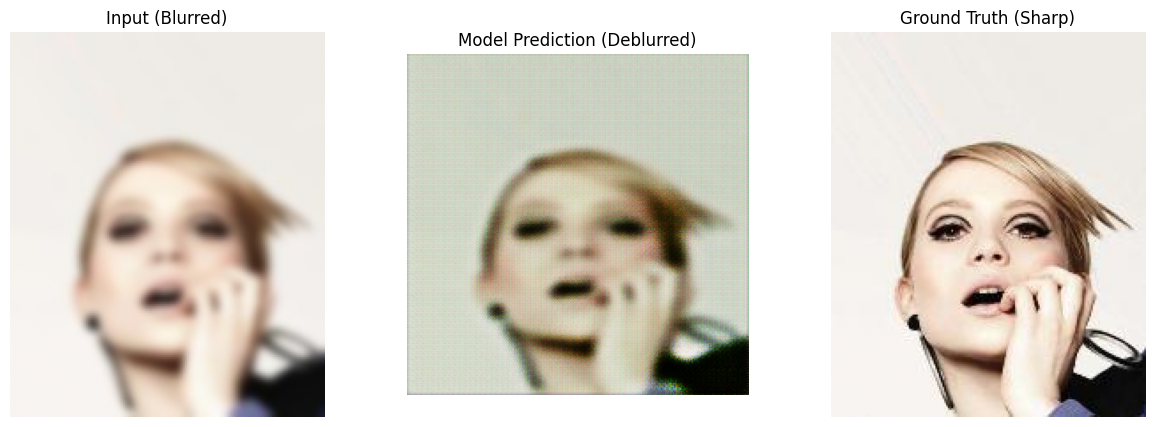

Testing on image: 100217.jpg


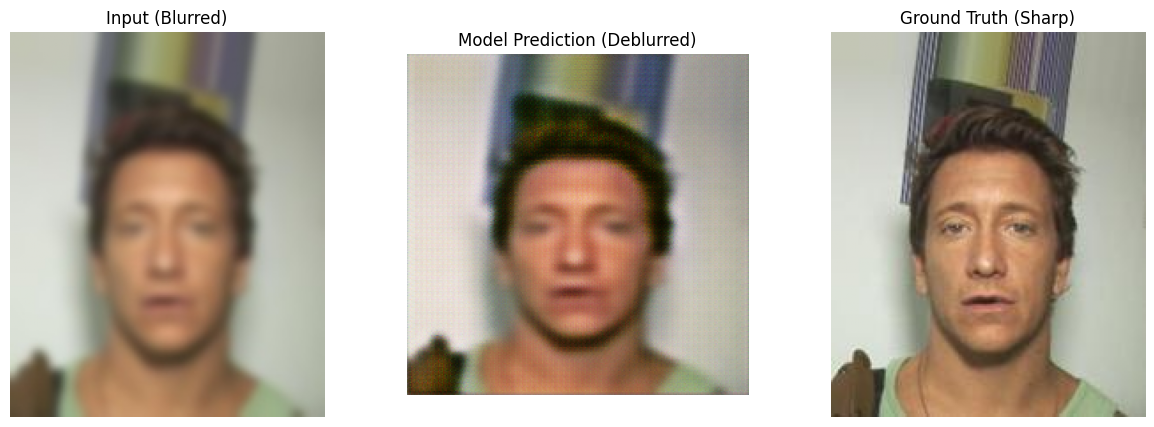

Testing on image: 100340.jpg


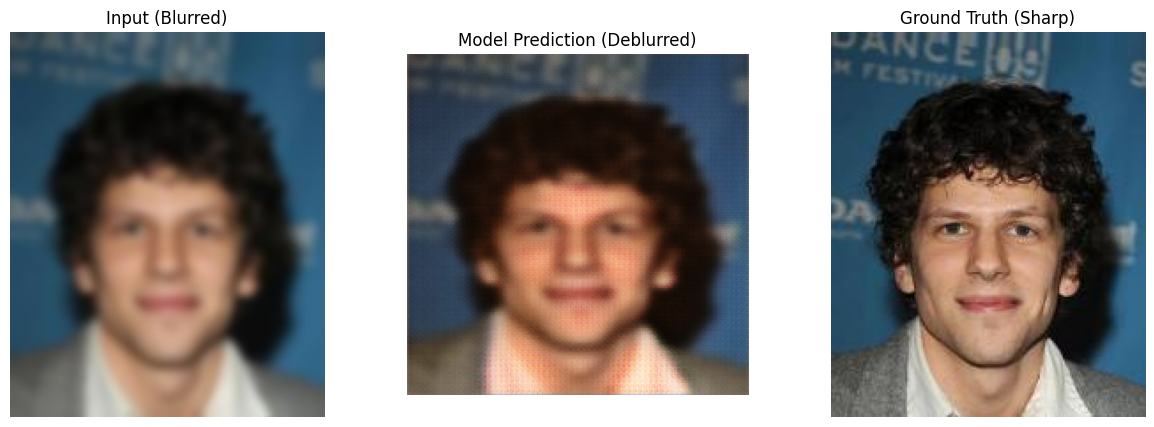

In [19]:
MODEL_PATH = '/content/generator_epoch_3.pth'   # FIXED PATH

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Loading the model
def load_checkpoint(filepath):
    print(f"Loading model from {filepath}...")
    gen = Generator().to(device)
    checkpoint = torch.load(filepath, map_location=device)
    gen.load_state_dict(checkpoint)
    gen.eval()
    return gen

# Visualization

Test_Blur_Dir = '/content/drive/MyDrive/dataset/blur'
Test_Sharp_Dir = '/content/drive/MyDrive/dataset/sharp'

def visualize_prediction(gen):
    files = sorted(os.listdir(Test_Blur_Dir))
    filename = random.choice(files)

    print(f"Testing on image: {filename}")

    blur_path = os.path.join(Test_Blur_Dir, filename)
    sharp_path = os.path.join(Test_Sharp_Dir, filename)

    blur_img = Image.open(blur_path).convert('RGB')
    sharp_img = Image.open(sharp_path).convert('RGB')

    img_tensor = test_transform(blur_img).unsqueeze(0).to(device)

    with torch.no_grad():
        fake_img = gen(img_tensor)

    # FIXED DISPLAY (no double normalization)
    import numpy as np
    blur_display = np.array(blur_img) / 255.0
    sharp_display = np.array(sharp_img) / 255.0
    generated_display = fake_img.squeeze().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(blur_display)
    axs[0].set_title("Input (Blurred)")
    axs[0].axis("off")

    axs[1].imshow(generated_display)
    axs[1].set_title("Model Prediction (Deblurred)")
    axs[1].axis("off")

    axs[2].imshow(sharp_display)
    axs[2].set_title("Ground Truth (Sharp)")
    axs[2].axis("off")

    plt.show()

# Load Model
trained_gen = load_checkpoint(MODEL_PATH)

# Show 3 random examples
for _ in range(3):
    visualize_prediction(trained_gen)

In [20]:
!pip install mtcnn
!pip install mtcnn lz4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.5 MB/s eta 0:00:00


In [21]:
!wget -O deploy.prototxt https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
!wget -O res10.caffemodel https://files.kde.org/digikam/facesengine/dnnface/res10_300x300_ssd_iter_140000_fp16.caffemodel

--2026-06-20 06:40:34--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt’

deploy.prototxt     100%[===================>]  27.45K  --.-KB/s    in 0s      

2026-06-20 06:40:35 (113 MB/s) - ‘deploy.prototxt’ saved [28104/28104]

--2026-06-20 06:40:35--  https://files.kde.org/digikam/facesengine/dnnface/res10_300x300_ssd_iter_140000_fp16.caffemodel
Resolving files.kde.org (files.kde.org)... 49.12.122.15, 2a01:4f8:242:53eb::4
Connecting to files.kde.org (files.kde.org)|49.12.122.15|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://mirror.freedif.org/KDE/files/digikam/facesengin

In [22]:
!ls -lh res10.caffemodel deploy.prototxt

-rw-r--r-- 1 root root  28K Jun 20 06:40 deploy.prototxt
-rw-r--r-- 1 root root 5.2M Oct  4  2020 res10.caffemodel


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# LOAD CNN MODEL (ResNet-10 SSD)
# =========================
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10.caffemodel")
print("CNN Face Detector loaded successfully!")

# =========================
# FACE DETECTION FUNCTION
# =========================
def detect_faces_cnn(image, confidence_threshold=0.5):
    """
    Detects faces in an image using CNN (ResNet-10 SSD).

    Args:
        image: numpy array (RGB) or PIL Image
        confidence_threshold: minimum confidence to keep detection (0.0 to 1.0)

    Returns:
        image_with_boxes: image with green bounding boxes drawn
        face_count: number of faces detected
    """
    # Convert PIL to numpy if needed
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Keep original for drawing
    output = image.copy()
    (h, w) = image.shape[:2]

    # Create blob from image (preprocessing for CNN)
    blob = cv2.dnn.blobFromImage(
        image,
        scalefactor=1.0,
        size=(300, 300),
        mean=(104.0, 177.0, 123.0),
        swapRB=False,  # OpenCV model expects BGR, but we handle via mean values
        crop=False
    )

    # Run CNN inference
    net.setInput(blob)
    detections = net.forward()

    face_count = 0

    # Loop over detections
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        # Filter weak detections
        if confidence > confidence_threshold:
            face_count += 1

            # Get bounding box coordinates
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype("int")

            # Draw bounding box (green)
            cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Draw confidence label
            label = f"{confidence:.2f}"
            cv2.putText(output, label, (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return output, face_count

# =========================
# DISPLAY FUNCTION
# =========================
def show_face_detection(image_path, title="Face Detection"):
    """
    Load image, detect faces, and display result.
    """
    # Load image
    img = Image.open(image_path).convert('RGB')
    img_np = np.array(img)

    # Detect faces
    result, count = detect_faces_cnn(img_np)

    # Display
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(result)
    axs[1].set_title(f"CNN Detection — Faces Found: {count}")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Faces detected: {count}")
    return result, count

CNN Face Detector loaded successfully!



Testing: 0.jpg


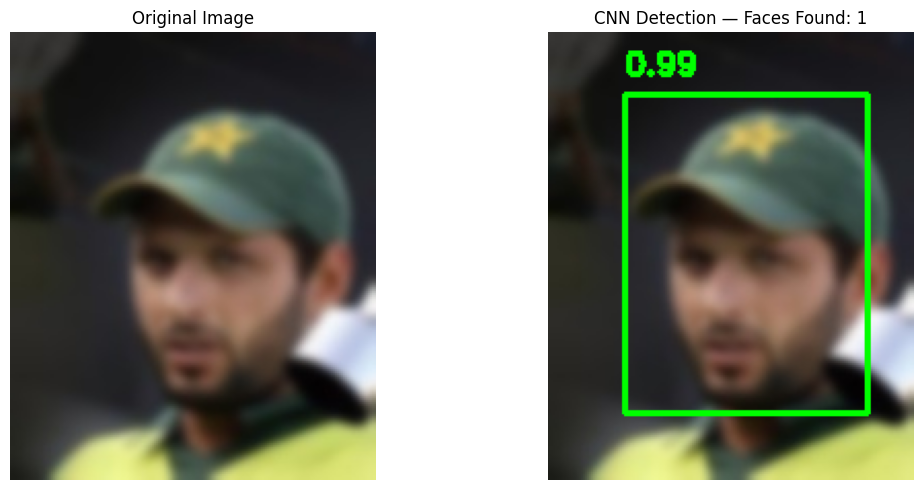

Faces detected: 1

Testing: 1.jpg


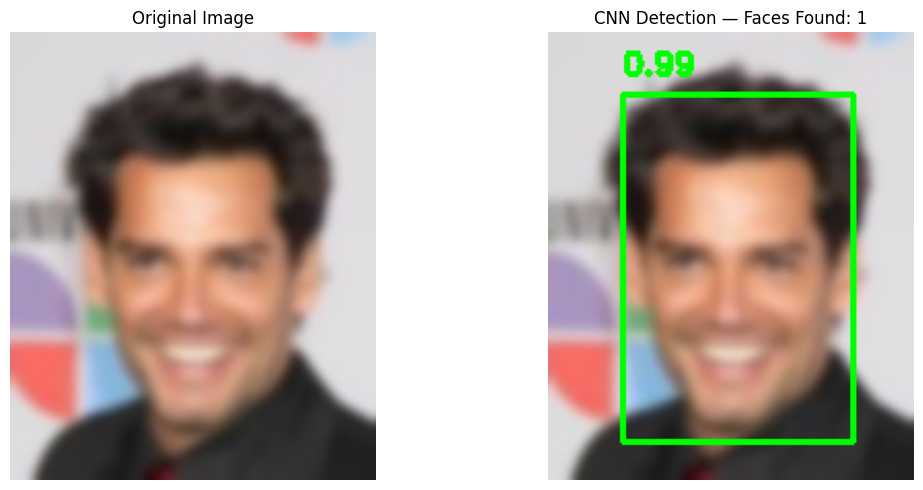

Faces detected: 1

Testing: 10.jpg


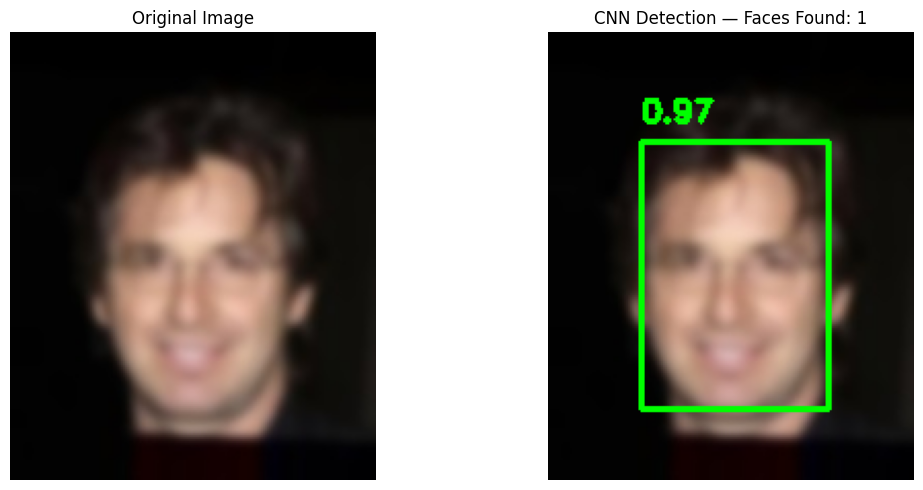

Faces detected: 1


In [24]:
import os

def test_multiple_images(folder_path, num_images=5):
    """
    Test face detection on multiple images from a folder.
    """
    files = sorted(os.listdir(folder_path))[:num_images]

    for file in files:
        img_path = os.path.join(folder_path, file)
        print(f"\nTesting: {file}")
        show_face_detection(img_path)

# Test on blur folder
test_multiple_images('/content/drive/MyDrive/dataset/blur', num_images=3)

In [26]:
trained_gen = load_checkpoint(MODEL_PATH)
trained_gen.to(device)

Loading model from /content/generator_epoch_3.pth...


Generator(
  (initial_down): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (down1): Block(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
      (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (down2): Block(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
      (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (down3): Block(
    (conv): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4,

In [27]:
img = Image.open('/content/drive/MyDrive/dataset/blur/0.jpg')
plt.imshow(process_image(np.array(img)))
plt.axis("off")

NameError: name 'detect_face_cnn' is not defined

In [30]:
!pip install gradio

import gradio as gr
import numpy as np
import cv2
import torch
from PIL import Image

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def process_image(input_img):
    try:
        # Convert input to PIL
        img = Image.fromarray(input_img).convert("RGB")

        # ===== GAN (Deblur) =====
        img_tensor = test_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            fake_img = trained_gen(img_tensor)

        # Convert GAN output
        generated = fake_img.squeeze().permute(1, 2, 0).cpu().numpy()
        generated = generated * 0.5 + 0.5
        generated = (generated * 255).astype('uint8')

        # ===== CNN FACE DETECTION =====
        generated_bgr = cv2.cvtColor(generated, cv2.COLOR_RGB2BGR)
        result = detect_face_cnn(generated_bgr)
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

        # ===== RESIZE (important for stacking) =====
        h, w, _ = input_img.shape
        generated = cv2.resize(generated, (w, h))
        result_rgb = cv2.resize(result_rgb, (w, h))

        # ===== COMBINE 3 IMAGES =====
        combined = np.hstack((input_img, generated, result_rgb))

        return combined

    except Exception as e:
        print("ERROR:", e)
        return input_img


# ===== UI =====
interface = gr.Interface(
    fn=process_image,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Image(type="numpy"),
    title="Face Detection from Blurred Image",
    description="Left: Blur | Middle: GAN Deblur | Right: CNN Face Detection"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://41daa989027d4f7a35.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
